# Cytokine prediction

In this section, we try to predict the cytokines for an unseen TCB

In [1]:
from __future__ import print_function, division
import os
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
import glob
from scifAI.ml import AutoFeatureSelection
from scifAI.utils import list_of_dict_to_dict
from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction import DictVectorizer
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
import sklearn
from sklearn.utils import shuffle
import skimage
plt.ion()   # interactive mode
from skimage.transform import   rescale, resize 
#from imageio import imread
import random
#import umap
from tqdm import tqdm
from random import sample
from skimage.transform import resize
import h5py
from skimage.exposure import rescale_intensity
import seaborn as sns
from umap import UMAP

In [2]:
from skimage.util import crop

def crop_pad_h_w(image_dummy,reshape_size):
    if image_dummy.shape[0] < reshape_size:
        h1_pad = ( reshape_size - image_dummy.shape[0])/2
        h1_pad = int(h1_pad)
        h2_pad =  reshape_size - h1_pad - image_dummy.shape[0]
        h1_crop = 0
        h2_crop = 0
    else:
        h1_pad = 0
        h2_pad = 0
        h1_crop = ( reshape_size - image_dummy.shape[0])/2
        h1_crop = abs(int(h1_crop))
        h2_crop = image_dummy.shape[0]- reshape_size  - h1_crop

    if image_dummy.shape[1] < reshape_size:
        w1_pad = (reshape_size - image_dummy.shape[1])/2
        w1_pad = int(w1_pad)
        w2_pad = reshape_size - w1_pad - image_dummy.shape[1]
        w1_crop = 0
        w2_crop = 0
    else:
        w1_pad = 0
        w2_pad = 0
        w1_crop = (reshape_size - image_dummy.shape[1])/2
        w1_crop = abs(int(w1_crop))
        w2_crop = image_dummy.shape[1]- reshape_size  - w1_crop

    h = [h1_crop, h2_crop, h1_pad, h2_pad]
    w = [w1_crop, w2_crop, w1_pad, w2_pad] 
    return h, w

In [3]:
color_map = np.array([
 
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.8352941176470589, 0.3686274509803922, 0.0),
    (0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8, 0.47058823529411764, 0.7372549019607844),
    (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2)])

lets load the data

In [4]:
metadata = pd.read_csv("/pstore/data/DS4/synapse_data_features/metadata_subset_with_predictions.csv.gz")
metadata

,file,experiment,donor,condition,object_number,set,label,prediction,entropy,key,outlier,cluster
0,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,5156,unlabeled,-1,B_cell,0.001350,Experiment_1 Donor_1,False,0
1,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,32020,unlabeled,-1,T_cell,0.000959,Experiment_1 Donor_1,False,1
2,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,55974,unlabeled,-1,Dead_Cell,0.002358,Experiment_1 Donor_1,False,0
3,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,15150,unlabeled,-1,T_cell,0.000502,Experiment_1 Donor_1,False,1
4,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_1,Donor_1,+SEA,44814,unlabeled,-1,B_cell_with_small_area,0.028317,Experiment_1 Donor_1,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1065962,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,72493,unlabeled,-1,T_cell_with_signaling,0.259178,Experiment_4 Donor_9,False,1
1065963,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,106656,unlabeled,-1,B_cell,0.006382,Experiment_4 Donor_9,False,0
1065964,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,110990,unlabeled,-1,T_cell_with_signaling,0.487638,Experiment_4 Donor_9,False,1
1065965,/pstore/data/DS4/synapse_formation_full_data/E...,Experiment_4,Donor_9,DIG-TCB,71451,unlabeled,-1,B_cell,0.082181,Experiment_4 Donor_9,False,2


In [5]:
indx = metadata.outlier.astype(str) == "True"
metadata.loc[indx, "outlier"] = 1
metadata.loc[~indx, "outlier"] = 0
metadata["outlier"] = metadata["outlier"].astype(int)

In [6]:

df_features = pd.read_csv("/pstore/data/DS4/synapse_data_features/df_features_subset.csv.gz")
df_features

,mask_based_area_BF,mask_based_bbox_area_BF,mask_based_convex_area_BF,mask_based_eccentricity_BF,mask_based_equivalent_diameter_BF,mask_based_euler_number_BF,mask_based_extent_BF,mask_based_feret_diameter_max_BF,mask_based_filled_area_BF,mask_based_major_axis_length_BF,...,max_intensity_ratio_MHCII_R7_R8,sum_intensity_ratio_CD3_R7_R8,mean_intensity_ratio_CD3_R7_R8,max_intensity_ratio_CD3_R7_R8,sum_intensity_ratio_P-CD3zeta_R7_R8,mean_intensity_ratio_P-CD3zeta_R7_R8,max_intensity_ratio_P-CD3zeta_R7_R8,sum_intensity_ratio_Live-Dead_R7_R8,mean_intensity_ratio_Live-Dead_R7_R8,max_intensity_ratio_Live-Dead_R7_R8
0,2228,3021,2392,0.484394,53.261409,1,0.737504,61.717096,2228,57.336477,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,885,1155,925,0.238094,33.568095,1,0.766234,36.138622,885,34.216438,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,656,812,689,0.369856,28.900608,1,0.807882,32.756679,656,30.262314,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,753,899,780,0.386491,30.963678,1,0.837597,34.132096,753,32.348559,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1208,1512,1247,0.661747,39.218279,1,0.798942,51.224994,1208,45.782110,...,19.735296,0.465222,0.465222,25.504583,0.481531,0.481531,26.397369,0.754085,0.754085,45.835530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065962,973,1190,997,0.100885,35.197473,1,0.817647,37.215588,973,35.332773,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1065963,3956,5046,4180,0.787555,70.971372,1,0.783987,91.760558,3956,91.437834,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1065964,909,1073,928,0.622298,34.020211,1,0.847158,40.804412,909,38.830446,...,5.716450,0.190820,0.190820,7.474995,0.115499,0.115499,4.191402,1.000000,1.000000,32.928658
1065965,3388,4272,3670,0.875994,65.679035,1,0.793071,90.426766,3388,96.830707,...,6.247939,0.039196,0.039196,124.378412,0.045108,0.045108,140.202637,0.005466,0.005466,16.385927


In [7]:
list_of_features_to_exclude = ["Antibody","Live-Dead","CD18",  "_R2",  "_R3",  "_R8", "background",
                               "moment","percent","mask_based_mean","mask_based_min","mask_based_max",  
                               "RMS","intensity_BF","_R1_R2","_R1_R3","_R1_R4","_R1_R5","_R1_R6","_R1_R7",
                               "_R1_R8","_R2_R1","_R2_R3","_R2_R4","_R2_R5","_R2_R6","_R2_R7","_R2_R8",
                               "_R3_R1","_R3_R2","_R3_R4","_R3_R5","_R3_R6","_R3_R7","_R3_R8",
                               "_R4_R1","_R4_R2","_R4_R3","_R4_R5","_R4_R6","_R4_R7","_R4_R8",
                               "_R5_R1","_R5_R2","_R5_R3","_R5_R4","_R5_R8","_R6_R1","_R6_R2",
                               "_R6_R3","_R6_R4","_R6_R5","_R6_R7","_R6_R8","_R7_R1","_R7_R2",
                               "_R7_R3","_R7_R4","_R7_R5","_R7_R6","_R7_R8","_R8_R1","_R8_R2",
                               "_R8_R3","_R8_R4","_R8_R5","_R8_R6","_R8_R7","cell_distance"]
classification_indx = ~df_features.columns.str.contains( list_of_features_to_exclude[0]) 

for f_to_exclude in list_of_features_to_exclude:
    classification_indx = classification_indx & ~df_features.columns.str.contains( f_to_exclude) 
    

print("list of remained columns:\n", 
      df_features.columns[classification_indx],
     "\n",
     "so we have these many columns:",
     classification_indx.sum())

list of remained columns:
 Index(['mask_based_area_BF', 'mask_based_bbox_area_BF',
       'mask_based_convex_area_BF', 'mask_based_eccentricity_BF',
       'mask_based_equivalent_diameter_BF', 'mask_based_euler_number_BF',
       'mask_based_extent_BF', 'mask_based_feret_diameter_max_BF',
       'mask_based_filled_area_BF', 'mask_based_major_axis_length_BF',
       ...
       'max_intensity_ratio_F-Actin_R5_R7', 'sum_intensity_ratio_MHCII_R5_R7',
       'mean_intensity_ratio_MHCII_R5_R7', 'max_intensity_ratio_MHCII_R5_R7',
       'sum_intensity_ratio_CD3_R5_R7', 'mean_intensity_ratio_CD3_R5_R7',
       'max_intensity_ratio_CD3_R5_R7', 'sum_intensity_ratio_P-CD3zeta_R5_R7',
       'mean_intensity_ratio_P-CD3zeta_R5_R7',
       'max_intensity_ratio_P-CD3zeta_R5_R7'],
      dtype='object', length=247) 
 so we have these many columns: 247


In [8]:
set_of_interesting_classes = ['B_cell',  'T_cell', 
                        'T_cell_with_signaling',
                        'B_T_cell_in_one_layer',
                        'Synapses_without_signaling', 
                        'Synapses_with_signaling',
                        'Multiplets'] 


we need to load the frequency data which was calculated previously

In [9]:
metadata_alive = pd.read_csv("/pstore/data/DS4/synapse_data_features/metadata_alive_with_predictions.csv")

In [10]:
metadata_alive.head()

,donor,experiment,condition,T_cell,T_cell_with_signaling,B_T_cell_in_one_layer,Synapses_without_signaling,Synapses_with_signaling,Multiplets,B_cell,key
0,Donor_1,Experiment_1,+SEA,36.94,7.92,2.53,2.92,1.60,3.48,44.62,Experiment_1 Donor_1
1,Donor_1,Experiment_1,-SEA,40.73,7.77,0.51,0.65,0.15,0.59,49.62,Experiment_1 Donor_1
2,Donor_1,Experiment_1,Isotype,32.20,8.65,2.43,2.86,1.78,5.23,46.84,Experiment_1 Donor_1
3,Donor_1,Experiment_1,Teplizumab,26.09,11.92,1.57,2.13,0.80,2.85,54.64,Experiment_1 Donor_1
4,Donor_2,Experiment_1,+SEA,33.35,7.18,2.31,2.12,1.83,2.91,50.29,Experiment_1 Donor_2


Finally, we need to add the cytokine values from flow cytometry

In [11]:
cytokine = pd.read_csv("cytokine_production.csv")


In [12]:
for i in range(len(cytokine)):
    if cytokine.loc[i,"condition"] == '"+SEA"':
        cytokine.loc[i,"condition"] = "+SEA"
    elif cytokine.loc[i,"condition"] == '"-SEA"':
        cytokine.loc[i,"condition"] = "-SEA"

In [13]:

cytokine = cytokine.loc[:,["donor",
                           "experiment",
                           "condition",
                           "TNFa", 
                           "GrzmB",
                           "IFNg",
                           "age",
                           "gender"]]
cytokine["TNFa"] = cytokine["TNFa"].fillna(-1.)
cytokine["GrzmB"] = cytokine["GrzmB"].fillna(-1.)
cytokine["IFNg"] = cytokine["IFNg"].fillna(-1.)
#cytokine["age"] = cytokine["age"].replace({'<30':"young",'30-50':"middle-age",'>50':"old" })

In [14]:
cytokine.head()

,donor,experiment,condition,TNFa,GrzmB,IFNg,age,gender
0,Donor_1,Experiment_1,+SEA,12.50,-1.0,-1.0,>50,male
1,Donor_1,Experiment_1,-SEA,0.33,-1.0,-1.0,>50,male
2,Donor_1,Experiment_1,Isotype,10.30,-1.0,-1.0,>50,male
3,Donor_1,Experiment_1,Abatacept,6.36,-1.0,-1.0,>50,male
4,Donor_1,Experiment_1,Teplizumab,5.83,-1.0,-1.0,>50,male


now lets merge the data

In [15]:
metadata_alive = pd.merge(metadata_alive, 
                             cytokine, 
                             how = "left", 
                             left_on=["donor","experiment","condition"],
                             right_on=["donor","experiment","condition"] )
metadata_alive = metadata_alive.dropna()

In [16]:
metadata_alive

,donor,experiment,condition,T_cell,T_cell_with_signaling,B_T_cell_in_one_layer,Synapses_without_signaling,Synapses_with_signaling,Multiplets,B_cell,key,TNFa,GrzmB,IFNg,age,gender
0,Donor_1,Experiment_1,+SEA,36.94,7.92,2.53,2.92,1.60,3.48,44.62,Experiment_1 Donor_1,12.50,-1.00,-1.00,>50,male
1,Donor_1,Experiment_1,-SEA,40.73,7.77,0.51,0.65,0.15,0.59,49.62,Experiment_1 Donor_1,0.33,-1.00,-1.00,>50,male
2,Donor_1,Experiment_1,Isotype,32.20,8.65,2.43,2.86,1.78,5.23,46.84,Experiment_1 Donor_1,10.30,-1.00,-1.00,>50,male
3,Donor_1,Experiment_1,Teplizumab,26.09,11.92,1.57,2.13,0.80,2.85,54.64,Experiment_1 Donor_1,5.83,-1.00,-1.00,>50,male
4,Donor_2,Experiment_1,+SEA,33.35,7.18,2.31,2.12,1.83,2.91,50.29,Experiment_1 Donor_2,10.40,-1.00,-1.00,30-50,female
5,Donor_2,Experiment_1,-SEA,38.47,7.12,0.74,0.93,0.09,0.59,52.04,Experiment_1 Donor_2,0.27,-1.00,-1.00,30-50,female
6,Donor_2,Experiment_1,Isotype,30.60,4.12,2.28,2.86,1.87,3.85,54.42,Experiment_1 Donor_2,10.70,-1.00,-1.00,30-50,female
7,Donor_2,Experiment_1,Teplizumab,19.06,19.38,1.66,1.60,0.64,3.16,54.51,Experiment_1 Donor_2,5.49,-1.00,-1.00,30-50,female
8,Donor_3,Experiment_2,+SEA,11.43,21.00,2.70,1.25,3.52,6.70,53.40,Experiment_2 Donor_3,13.60,-1.00,-1.00,30-50,male
9,Donor_3,Experiment_2,-SEA,15.20,19.37,1.12,0.93,0.96,1.71,60.70,Experiment_2 Donor_3,0.45,-1.00,-1.00,30-50,male


lets clean the values

In [17]:

#metadata_alive.iloc[:,5:-2] =metadata_alive.iloc[:,5:-2].astype(float)
metadata_alive.iloc[:,3:-6] =metadata_alive.iloc[:,3:-6].astype(float)
metadata_alive["TNFa"] = metadata_alive["TNFa"].astype(float)
metadata_alive["GrzmB"] = metadata_alive["GrzmB"].astype(float)
metadata_alive["IFNg"] = metadata_alive["IFNg"].astype(float)

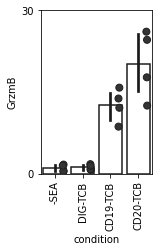

In [18]:
fig , ax = plt.subplots(1, figsize = (0.5*4,3) )

indx = metadata_alive["experiment"] == "Experiment_4"

ax = sns.barplot(data = metadata_alive.loc[indx,:] , 
                       x = "condition",
                       y = "GrzmB", 
                       order = [ "-SEA",'DIG-TCB', 'CD19-TCB', 'CD20-TCB'], 
                     linewidth=1.5, facecolor=(1, 1, 1, 0),
                     errcolor=".1", edgecolor=".1",
                ax=ax) 


ax = sns.stripplot(data = metadata_alive.loc[indx,:] , 
                       x = "condition",
                       y = "GrzmB", 
                       hue = "experiment", 
                       order = ["-SEA",'DIG-TCB', 'CD19-TCB', 'CD20-TCB'],
                       hue_order = [
                                    "Exp_1",
                                    "Exp_2",
                                    "Exp_3",
                                    "Experiment_4"],
                       s = 7,
                       linewidth=1,
                       split = True,
                      palette=np.array([(1,1,1 ),
                                        (0.85, 0.85, 0.85 ),
                                        (0.60, 0.60, 0.60 ),
                                        (0.2,0.2,0.2 )]), 
                       dodge=False,
                      ax = ax) 


ax.legend().remove()
ax.set_xticklabels(["-SEA",'DIG-TCB', 'CD19-TCB', 'CD20-TCB'], rotation = "vertical")
ax.set_yticks([0, 30]   )
ax.set_ylim(0,30 )

plt.savefig('Figure - GrzmB frequencies - experiment four.png', bbox_inches="tight")
plt.savefig('Figure - GrzmB frequencies - experiment four.svg', bbox_inches="tight")

# Feature aggregation

Here we aggregate the features using 5th, 50th and 95th percentile

In [19]:
indx = metadata["prediction"].isin(["Synapses_without_signaling","Synapses_with_signaling"])#
indx = metadata["outlier"].isin([0])#

columns_of_interest = classification_indx & (~df_features.columns.str.contains("BF"))


percentile_05_values = pd.concat([metadata.loc[indx,["donor","experiment","condition"]], 
                           df_features.loc[indx,columns_of_interest]], 
                          axis = 1).groupby(["donor","experiment","condition"]).quantile(0.05).reset_index()
percentile_05_values = percentile_05_values.loc[:, ["donor","experiment","condition"] +   (percentile_05_values.std() > 0.).index.tolist()]

percentile_50_values = pd.concat([metadata.loc[indx,["donor","experiment","condition"]], 
                           df_features.loc[indx,columns_of_interest]], 
                          axis = 1).groupby(["donor","experiment","condition"]).quantile(0.50).reset_index()
percentile_50_values = percentile_50_values.loc[:, ["donor","experiment","condition"] +   (percentile_50_values.std() > 0.).index.tolist()]


percentile_95_values = pd.concat([metadata.loc[indx,["donor","experiment","condition"]], 
                           df_features.loc[indx,columns_of_interest]],  
                          axis = 1).groupby(["donor","experiment","condition"]).quantile(0.95).reset_index()
percentile_95_values = percentile_95_values.loc[:, ["donor","experiment","condition"] +   (percentile_95_values.std() > 0.).index.tolist()]



In [20]:
percentile_05_values_names = dict()
for col in percentile_05_values.columns.values[3:]:
    percentile_05_values_names[col] = col + "_05"
percentile_05_values = percentile_05_values.rename(columns=percentile_05_values_names)

percentile_50_values_names = dict()
for col in percentile_50_values.columns.values[3:]:
    percentile_50_values_names[col] = col + "_50"
percentile_50_values = percentile_50_values.rename(columns=percentile_50_values_names)


percentile_95_values_names = dict()
for col in percentile_95_values.columns.values[3:]:
    percentile_95_values_names[col] = col + "_95"
percentile_95_values = percentile_95_values.rename(columns=percentile_95_values_names)

In [21]:
metadata_alive = pd.merge(metadata_alive, 
                             percentile_05_values, 
                             how = "left", 
                             left_on=["donor","experiment", "condition"],
                             right_on=["donor","experiment", "condition"] )

metadata_alive = pd.merge(metadata_alive, 
                             percentile_50_values, 
                             how = "left", 
                             left_on=["donor","experiment", "condition"],
                             right_on=["donor","experiment", "condition"] )

metadata_alive = pd.merge(metadata_alive, 
                             percentile_95_values, 
                             how = "left", 
                             left_on=["donor","experiment", "condition"],
                             right_on=["donor","experiment", "condition"] )

In [22]:
metadata_alive

,donor,experiment,condition,T_cell,T_cell_with_signaling,B_T_cell_in_one_layer,Synapses_without_signaling,Synapses_with_signaling,Multiplets,B_cell,...,max_intensity_ratio_F-Actin_R5_R7_95,sum_intensity_ratio_MHCII_R5_R7_95,mean_intensity_ratio_MHCII_R5_R7_95,max_intensity_ratio_MHCII_R5_R7_95,sum_intensity_ratio_CD3_R5_R7_95,mean_intensity_ratio_CD3_R5_R7_95,max_intensity_ratio_CD3_R5_R7_95,sum_intensity_ratio_P-CD3zeta_R5_R7_95,mean_intensity_ratio_P-CD3zeta_R5_R7_95,max_intensity_ratio_P-CD3zeta_R5_R7_95
0,Donor_1,Experiment_1,+SEA,36.94,7.92,2.53,2.92,1.60,3.48,44.62,...,17.231964,1.000000,1.000000,94.137009,1.0,1.0,154.724506,1.0,1.0,144.011701
1,Donor_1,Experiment_1,-SEA,40.73,7.77,0.51,0.65,0.15,0.59,49.62,...,16.945773,1.000000,1.000000,118.917612,1.0,1.0,172.193866,1.0,1.0,158.174368
2,Donor_1,Experiment_1,Isotype,32.20,8.65,2.43,2.86,1.78,5.23,46.84,...,17.244169,1.000000,1.000000,71.459090,1.0,1.0,176.319096,1.0,1.0,163.083649
3,Donor_1,Experiment_1,Teplizumab,26.09,11.92,1.57,2.13,0.80,2.85,54.64,...,15.902009,1.000000,1.000000,61.509288,1.0,1.0,199.778167,1.0,1.0,192.556106
4,Donor_2,Experiment_1,+SEA,33.35,7.18,2.31,2.12,1.83,2.91,50.29,...,15.943551,1.000000,1.000000,88.576089,1.0,1.0,159.197169,1.0,1.0,138.222815
5,Donor_2,Experiment_1,-SEA,38.47,7.12,0.74,0.93,0.09,0.59,52.04,...,14.544268,1.000000,1.000000,106.777680,1.0,1.0,172.917123,1.0,1.0,152.508305
6,Donor_2,Experiment_1,Isotype,30.60,4.12,2.28,2.86,1.87,3.85,54.42,...,15.282510,1.000000,1.000000,102.340207,1.0,1.0,160.704601,1.0,1.0,130.092484
7,Donor_2,Experiment_1,Teplizumab,19.06,19.38,1.66,1.60,0.64,3.16,54.51,...,16.078853,1.000000,1.000000,42.982874,1.0,1.0,176.374173,1.0,1.0,172.414345
8,Donor_3,Experiment_2,+SEA,11.43,21.00,2.70,1.25,3.52,6.70,53.40,...,19.635853,1.000000,1.000000,48.341818,1.0,1.0,206.135958,1.0,1.0,201.817903
9,Donor_3,Experiment_2,-SEA,15.20,19.37,1.12,0.93,0.96,1.71,60.70,...,17.358684,1.000000,1.000000,59.103036,1.0,1.0,208.540709,1.0,1.0,187.709459


In [23]:
metadata_alive.corr()["TNFa"].loc[set_of_interesting_classes ].sort_values()

T_cell                       -0.308472
T_cell_with_signaling        -0.257511
Synapses_without_signaling   -0.252842
B_cell                        0.104661
Multiplets                    0.399183
Synapses_with_signaling       0.547961
B_T_cell_in_one_layer         0.573356
Name: TNFa, dtype: float64

In [24]:
indx = metadata_alive["condition"].isin(["-SEA",'DIG-TCB',  'CD19-TCB', 'CD20-TCB'])
metadata_alive.loc[indx,:].groupby("experiment").corr().abs().reset_index().groupby("level_1").mean()["TNFa"].sort_values(ascending=False).head(10)

level_1
TNFa                                                1.000000
max_intensity_P-CD3zeta_95                          0.986892
mean_intensity_P-CD3zeta_95                         0.985175
std_intensity_P-CD3zeta_95                          0.983192
structural_similarity_R4_F-Actin_R7_P-CD3zeta_95    0.981945
structural_similarity_R7_P-CD3zeta_R4_F-Actin_95    0.981945
correlation_F-Actin_05                              0.974962
homogeneity_P-CD3zeta_95                            0.974744
shannon_entropy_P-CD3zeta_95                        0.963586
mask_based_solidity_F-Actin_50                      0.963037
Name: TNFa, dtype: float64

# CD19-TCB and CD20-TCB prediction

In this part, we use a preselected features based on the biology and using Lasso Lars, we predict the cytokines

In [266]:

general_cols = []
general_cols += [
    
    "mean_intensity_ratio_F-Actin_R5_R6", 
    "mean_intensity_ratio_MHCII_R5_R6", 
    "mean_intensity_ratio_CD3_R5_R6", 
    "mean_intensity_ratio_P-CD3zeta_R5_R6",
    
    "dissimilarity_F-Actin",
    "dissimilarity_MHCII",
    "dissimilarity_CD3",
    "dissimilarity_P-CD3zeta",
    
    'correlation_F-Actin',
    'correlation_MHCII',
    'correlation_CD3',
    'correlation_P-CD3zeta',
    
    'mask_based_solidity_F-Actin',
    'mask_based_solidity_MHCII',
    'mask_based_solidity_CD3',
    'mask_based_solidity_P-CD3zeta',
    
    "mask_based_eccentricity_F-Actin",
    "mask_based_eccentricity_MHCII",
    "mask_based_eccentricity_CD3",
    "mask_based_eccentricity_P-CD3zeta",   
    
    'mean_intensity_F-Actin',
    'mean_intensity_MHCII',
    'mean_intensity_CD3',
    'mean_intensity_P-CD3zeta',
    
    'std_intensity_F-Actin',
    'std_intensity_MHCII',
    'std_intensity_CD3',
    'std_intensity_P-CD3zeta',
]    


general_cols = set(general_cols)
general_cols = list(general_cols)
 

cols_ = []
for gc in general_cols:
    
    cols_ += [gc + "_05"]
    cols_ += [gc + "_50"]
    cols_ += [gc + "_95"]
    
    
cols_ = set(cols_)
cols_ = list(cols_)


In [273]:
from sklearn.metrics import fbeta_score, make_scorer, mean_squared_log_error, mean_squared_error, r2_score
from scipy.stats import spearmanr, pearsonr

def scorr_logloss(ground_truth, predictions):
    
    s_corr = spearmanr(ground_truth,predictions)
    r2 = r2_score(ground_truth,predictions)
    logloss = mean_squared_log_error(ground_truth,predictions)
    
    return s_corr[0] + 0.8*r2 - logloss

In [268]:
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import (Lasso, 
                                  LassoCV, 
                                  ElasticNet,
                                  ElasticNetCV, 
                                  RidgeCV, 
                                  Ridge, 
                                  LassoLarsIC, 
                                  LassoLarsCV, 
                                  LinearRegression,
                                  HuberRegressor, 
                                  LassoLars)
from sklearn.linear_model import (
    LinearRegression,
    TheilSenRegressor,
    RANSACRegressor,
    HuberRegressor,
)
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_validate, cross_val_predict
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.feature_selection import f_regression, f_classif, VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures


preds = []
most_important_features = dict()
for cond in ['CD19-TCB','CD20-TCB']:
    train_conds  = ["-SEA", 'DIG-TCB', 'CD19-TCB','CD20-TCB']
    train_conds.remove(cond)
    
    train_indx = metadata_alive["condition"].isin(train_conds)
    train_indx = train_indx & metadata_alive["experiment"].isin(["Experiment_4"])     
    train_indx = train_indx[train_indx].index
    print("train", train_conds, len(train_indx))

    
    test_indx = metadata_alive["condition"].isin([cond])
    test_indx = test_indx & metadata_alive["experiment"].isin(["Experiment_4"])
    print("test", [cond], test_indx.sum())  
    
 
    lm_GrzmB =  Pipeline([ 
            ("VarianceThreshold", VarianceThreshold(0.)), 
            ("StandardScaler", StandardScaler()),
            ('LassoLars',  TransformedTargetRegressor(regressor =LassoLars(random_state = 3 ),
                                                     transformer=StandardScaler()))
    ]) 
    

    parameters = {
                  'LassoLars__regressor__alpha': np.linspace(1e-16,7,100), 
                  'LassoLars__regressor__jitter':np.linspace(-1.,1.,20), 
                  'LassoLars__regressor__fit_intercept':[True,False],
                 }
    
    lm_GrzmB = GridSearchCV(lm_GrzmB, 
                           parameters, 
                           n_jobs = -1, 
                           cv = LeaveOneGroupOut(),
                           refit=True,
                           verbose = 3,
                          scoring=make_scorer(scorr_logloss, greater_is_better=True), 
                          )
    
    lm_GrzmB = lm_GrzmB.fit(metadata_alive.loc[train_indx, cols_ ].to_numpy(), 
                metadata_alive.loc[train_indx, "GrzmB"].to_numpy(),
                         groups = metadata_alive.loc[train_indx, "donor"].to_numpy()
                         )    
    print(lm_GrzmB.best_params_)
    print("____________________________")
    selected_features = np.array(cols_)[lm_GrzmB.best_estimator_.steps[0][-1].get_support()]
    most_important_features[cond] = dict()
    for i, selected_f in enumerate(selected_features):
        coef_value = lm_GrzmB.best_estimator_.steps[-1][1].regressor_.coef_[i]
        if  coef_value!= 0.:
            most_important_features[cond][selected_f] = coef_value 
    
    for k in range(test_indx.sum()):
        preds.append([metadata_alive.loc[test_indx, "GrzmB"].tolist()[k] ,  
                 lm_GrzmB.predict(metadata_alive.loc[test_indx, cols_].to_numpy())[k], 
                     metadata_alive.loc[test_indx, "condition"].tolist()[k] , 
                     metadata_alive.loc[test_indx, "donor"].tolist()[k], 
                     metadata_alive.loc[test_indx, "experiment"].tolist()[k]]  ) 
        
#ax[-1,1].set_ylim([-0.1,1.5])

train ['-SEA', 'DIG-TCB', 'CD20-TCB'] 12
test ['CD19-TCB'] 4
Fitting 4 folds for each of 4000 candidates, totalling 16000 fits
{'LassoLars__regressor__alpha': 1e-16, 'LassoLars__regressor__fit_intercept': True, 'LassoLars__regressor__jitter': -1.0}
____________________________
train ['-SEA', 'DIG-TCB', 'CD19-TCB'] 12
test ['CD20-TCB'] 4
Fitting 4 folds for each of 4000 candidates, totalling 16000 fits
{'LassoLars__regressor__alpha': 1e-16, 'LassoLars__regressor__fit_intercept': True, 'LassoLars__regressor__jitter': -1.0}
____________________________


In [269]:
preds = pd.DataFrame(preds, columns=["GrzmB", "GrzmB_preds","condition","donor","experiment"])

preds

,GrzmB,GrzmB_preds,condition,donor,experiment
0,8.63,9.646213,CD19-TCB,Donor_2,Experiment_4
1,13.80,6.083942,CD19-TCB,Donor_7,Experiment_4
2,15.80,13.813869,CD19-TCB,Donor_8,Experiment_4
3,12.10,10.380960,CD19-TCB,Donor_9,Experiment_4
4,26.10,17.547901,CD20-TCB,Donor_2,Experiment_4
5,12.50,17.011508,CD20-TCB,Donor_7,Experiment_4
6,24.60,21.274862,CD20-TCB,Donor_8,Experiment_4
7,17.70,16.191466,CD20-TCB,Donor_9,Experiment_4


In [270]:
print( "MSLE", round( mean_squared_error(preds["GrzmB"],preds["GrzmB_preds"]),2)   )


MSLE 21.79


In [274]:
print( "r2_score", round( r2_score(preds["GrzmB"],preds["GrzmB_preds"]),2)   )

r2_score 0.34


In [275]:
print("Spearamn corr", round(spearmanr(preds["GrzmB"],preds["GrzmB_preds"])[0],2)   )

Spearamn corr 0.71


In [276]:
print("Pearson corr", round(pearsonr(preds["GrzmB"],preds["GrzmB_preds"])[0],2))

Pearson corr 0.72


In [277]:
lm_GrzmB.best_params_

{'LassoLars__regressor__alpha': 1e-16,
 'LassoLars__regressor__fit_intercept': True,
 'LassoLars__regressor__jitter': -1.0}

In [278]:
most_important_features

{'CD19-TCB': {'mask_based_solidity_CD3_95': 0.08460859114934483,
  'mean_intensity_ratio_F-Actin_R5_R6_50': 0.013896568050895156,
  'dissimilarity_P-CD3zeta_50': 0.022295120211863948,
  'correlation_MHCII_95': -0.024954116820016994,
  'correlation_F-Actin_05': -0.9929994852695283,
  'dissimilarity_MHCII_05': -0.2482237813572048,
  'mask_based_eccentricity_MHCII_05': 0.009186002662829408,
  'mean_intensity_ratio_MHCII_R5_R6_95': 0.1026212487960757,
  'correlation_CD3_50': 0.12497998350598938,
  'mask_based_eccentricity_F-Actin_95': 0.22806415485200177,
  'correlation_P-CD3zeta_05': -0.08774081040576276},
 'CD20-TCB': {'mask_based_solidity_CD3_95': 0.0027892961568787215,
  'correlation_F-Actin_05': -0.22924886636607178,
  'mask_based_eccentricity_P-CD3zeta_95': 0.10260805201482281,
  'mean_intensity_CD3_50': 0.0016837166366447393,
  'mean_intensity_ratio_F-Actin_R5_R6_95': 0.17612567179749872,
  'dissimilarity_P-CD3zeta_05': -0.23446648738081508,
  'mask_based_eccentricity_MHCII_05': 0.0

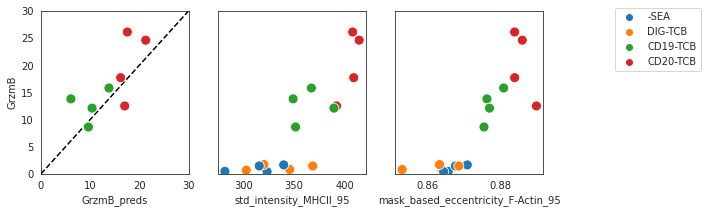

In [279]:
sns.set_style("white")
fig, ax = plt.subplots(ncols = 3,figsize = (9,3), sharey = True)

ax[0].axline([0.5, 0.5], [0.8, 0.8], c = "k",  ls = "--")
ax[0] = sns.scatterplot(data = pd.DataFrame(preds),
    x = "GrzmB_preds" ,
              y ="GrzmB", 
                     s = 100,
                     hue = "condition", 
                     hue_order = ["-SEA",'DIG-TCB',"CD19-TCB","CD20-TCB"],
                     ax = ax[0], 
                     zorder = 10
                    )
ax[0].legend(bbox_to_anchor=(1.1, 1.05)).remove()
ax[0].set_xlim(0,30)
ax[0].set_ylim(0,30)


row_index  = ["-SEA",'DIG-TCB', 'CD19-TCB','CD20-TCB']
    
row_index = metadata_alive["condition"].isin(row_index)
row_index = row_index & metadata_alive["experiment"].isin(["Experiment_4"])     

ax[1] = sns.scatterplot(data = metadata_alive.loc[row_index,:],
    x = "std_intensity_MHCII_95" ,
              y ="GrzmB", 
                     s = 100,
                     hue = "condition", 
                     hue_order = ["-SEA",'DIG-TCB', 'CD19-TCB','CD20-TCB'],
                     ax = ax[1], 
                     zorder = 10
                    )
ax[1].legend(bbox_to_anchor=(2.1, 1.05)).remove()
#ax[1].set_xlim(250,500)
ax[1].set_ylim(0,30)

ax[2] = sns.scatterplot(data = metadata_alive.loc[row_index,:],
    x = "mask_based_eccentricity_F-Actin_95" ,
              y ="GrzmB", 
                     s = 100,
                     hue = "condition", 
                     hue_order = ["-SEA",'DIG-TCB', 'CD19-TCB','CD20-TCB'],
                     ax = ax[2], 
                     zorder = 10
                    )
ax[2].legend(bbox_to_anchor=(2.1, 1.05))
#ax[1].set_xlim(250,500)
ax[2].set_ylim(0,30)

plt.savefig('Figure5 - CD20 CD19 GrmzB.png', bbox_inches="tight")
plt.savefig('Figure5 - CD20 CD19 GrmzB.svg', bbox_inches="tight")

## sample images

Now lets take a look at 5 randomly sampled images from -SEA, Ctrl-TCB, CD19-TCB and CD20-TCB

[345.0, 6.0, 50.0, 29.0, 39.0, 49.0, 41.0] [1094.0, 583.7200000000012, 702.6499999999996, 1974.3399999999965, 1696.2000000000135, 1017.3899999999994, 181.15000000000055]


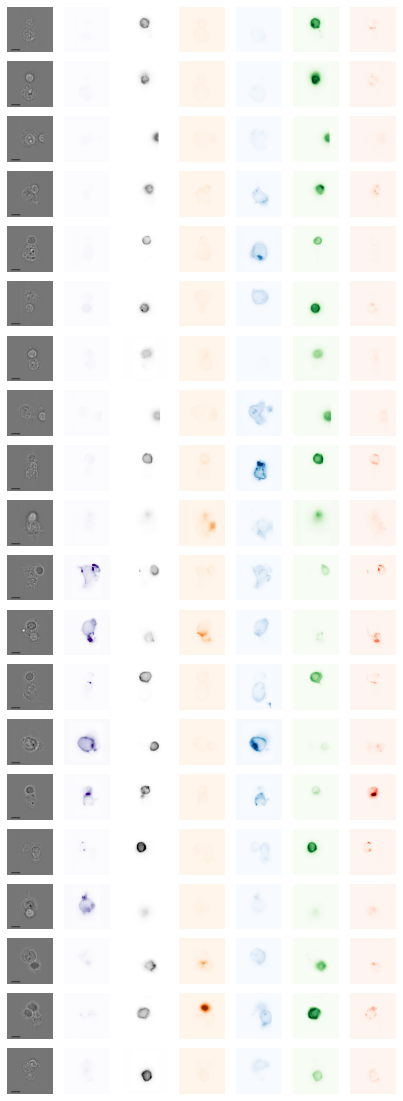

In [253]:
k = 5
image_size = 128
channels_to_be_plotted = [0,1,2,3,4,5,6]
channel_colors = ["Greys", "Purples","Greys","Oranges" ,"Blues", "Greens","Reds"]

indx1 = metadata["donor"] == "Donor_8"
indx1 = indx1&(metadata["experiment"] == "Experiment_4")
indx1 = indx1&(metadata["prediction"].isin(["Synapses_without_signaling", "Synapses_with_signaling"])) # Synapses
indx1 = indx1&(metadata["outlier"].isin([0]))
indx1 = indx1&(metadata["condition"].isin(["-SEA"]))
indx1 = indx1[indx1].sample(k,replace=True).index.tolist()

indx2 = metadata["donor"] == "Donor_8"
indx2 = indx2&(metadata["experiment"] == "Experiment_4")
indx2 = indx2&(metadata["prediction"].isin(["Synapses_without_signaling", "Synapses_with_signaling"])) # Synapses
indx2 = indx2&(metadata["outlier"].isin([0]))
indx2 = indx2&(metadata["condition"].isin(["DIG-TCB"]))
indx2 = indx2[indx2].sample(k,replace=True).index.tolist()

indx3 = metadata["donor"] == "Donor_8"
indx3 = indx3&(metadata["experiment"] == "Experiment_4")
indx3 = indx3&(metadata["prediction"].isin(["Synapses_without_signaling", "Synapses_with_signaling"])) # Synapses
indx3 = indx3&(metadata["outlier"].isin([0]))
indx3 = indx3&(metadata["condition"].isin(["CD19-TCB"]))
indx3 = indx3[indx3].sample(k,replace=True).index.tolist()


indx4 = metadata["donor"] == "Donor_8"
indx4 = indx4&(metadata["experiment"] == "Experiment_4")
indx4 = indx4&(metadata["prediction"].isin(["Synapses_without_signaling", "Synapses_with_signaling"])) # Synapses
indx4 = indx4&(metadata["outlier"].isin([0]))
indx4 = indx4&(metadata["condition"].isin(["CD20-TCB" ]))
indx4 = indx4[indx4].sample(k,replace=True).index.tolist()

indx1 = sorted(indx1)
indx2 = sorted(indx2)
indx3 = sorted(indx3)
indx4 = sorted(indx4)


files = metadata.loc[indx1 + indx2 + indx3+indx4,:].sort_values("object_number")["file"].tolist()

nrows = len(files)
ncols = len(channels_to_be_plotted)

fix,ax = plt.subplots(nrows, ncols, figsize = ( ncols*1, nrows*1 ))
    
vmin = [4095.]*ncols
vmax = [0.]*ncols

for i in range(nrows):
    h5_file_ = h5py.File(files[i], "r")
    image = h5_file_.get("image")[()]
    mask = h5_file_.get("mask")[()]
    for j, ch in enumerate(channels_to_be_plotted):
        if j>0:
            vmin[j] = min(vmin[j], np.quantile(image[:,:,ch], 0.60)  )
            vmax[j] = max(vmax[j], np.quantile(image[:,:,ch], 0.99)  )
        else:
            vmin[j] = min(vmin[j], np.quantile(image[:,:,ch], 0.0)  )
            vmax[j] = max(vmax[j], np.quantile(image[:,:,ch], 1.0)  )

        
print(vmin,vmax)
for i in range(nrows):
    h5_file_ = h5py.File(files[i], "r")
    image = h5_file_.get("image")[()]
    h, w = crop_pad_h_w(image, image_size)
    h1_crop, h2_crop, h1_pad, h2_pad =  h 
    w1_crop, w2_crop, w1_pad, w2_pad = w 
    for j, ch in enumerate(channels_to_be_plotted):
            image_dummy = crop(image[:,:,ch], ((h1_crop,h2_crop),(w1_crop,w2_crop)))
            image_dummy = np.pad(image_dummy, 
                                     ((h1_pad,h2_pad),(w1_pad,w2_pad)), 
                                     'constant', 
                                     constant_values=np.median(image_dummy) )
            if j == 0:
                image_dummy[int(0.95*image_size):int(0.95*image_size+2), 
                            int(0.1*image_size):int(0.1*image_size  +25)] = vmax[j]
            ax[i,j].imshow(image_dummy, cmap = channel_colors[j] , vmin = vmin[j], vmax = vmax[j]  )
            ax[i,j].axis('off')
    h5_file_.close()

